In [19]:
# This Notebook is used to analyse the noise performances of the DRE from data files


In [20]:
# imports
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
import os
import readData as rddt
import constants as cst


In [21]:
#path = '/Users/laurent/data/20241011-2/'
path = '/Users/laurent/data/TestPlan21-perfo/errorNoise_20241014/'



In [22]:
# Parameters for the spectral analysis. The unit seems to be per sqrt(Hz). I don't know why...
xlabel = r'Frequencies $(Hz)$'
#ylabel = r'Noise $\left(V_{rms} /\sqrt{Hz}\right)$'
ylabel = r'Noise $\left( \frac{V_{rms}} {\sqrt{Hz}} \right)$'
scaling = 'spectrum'
#scaling = 'density'
ymin = 1e-9
ymax = 1e-5

In [23]:
def NoisePowerDensity_old(voltage, fs, nSamples = 2**16):

    # Slicing the data in several records
    nRecords = int(len(voltage)/nSamples)

    xf, dsp = signal.periodogram(voltage[:nSamples], fs, scaling=scaling)

    for record in range(nRecords-1):
        _, dspi = signal.periodogram(voltage[(record+1)*nSamples:(record+2)*nSamples], fs, scaling=scaling)
        dsp += dspi
    dsp /= nRecords

    return xf, dsp


In [24]:
def NoisePowerDensity(voltage, fs, nSamples = 2**16, verbose=False):

    # Slicing the data in several records
    nRecords = int(len(voltage)/nSamples) * 2 -1

    xf, dsp = signal.periodogram(voltage[:nSamples], fs, scaling=scaling)

    for record in range(nRecords-1):
        sig = voltage[int((record+1)*nSamples/2):int((record+3)*nSamples/2)]
        _, dspi = signal.periodogram(sig, fs, scaling=scaling)
        dsp += dspi
    dsp /= nRecords

    rmsInTime = voltage.std()
    rmsInFreq = np.sqrt(dsp[1:].sum())
    if verbose:
        print("rms in time: ", rmsInTime)
        print("rms in frequencies: ", rmsInFreq)
        
    # rmsInTime = Sigma (dsp[1:]) then dsp should be normalized
    # print("/BEFORE/ ", rmsInTime, "   ", np.sqrt(dsp[-10]*fs/2))
    dsp = dsp * len(dsp) / (fs / 2)
    # print("/AFTER/ ", rmsInTime, "   ", np.sqrt(dsp[-10]*fs/2))

    return xf, dsp, rmsInTime, rmsInFreq


In [32]:
def NoisePowerDensityFromDumps(path, colId, verbose=False):

    npts = cst.nSamplesPerRow*cst.muxFactor

    files = [f for f in os.listdir(path) \
                    if os.path.isfile(os.path.join(path, f)) \
                    and f[-5:]==".fits" and f[:5]=="dump_"]
    
    nFiles = len(files)
    print("Processing {0:} files".format(nFiles))

    WelchFactor = 1
    dspDumps = np.zeros((int(npts/(2*WelchFactor))+1))
    for index, file in enumerate(files):
        if verbose:
            print("Processing science file {0:}".format(index), file)
        columns, errors = rddt.readDumpFile(os.path.join(path, file))
        
        # Converting data in engineering values
        voltage = columns[colId] * cst.fsrAdcError / 2**cst.nBitsAdcErrInDumps
        
        xf, dsp, rmsInTime, rmsInFreq = NoisePowerDensity(voltage, cst.fSamp, int(cst.muxFactor*cst.nSamplesPerRow/WelchFactor), verbose)
        dspDumps += dsp

    return xf, dsp / len(files), rmsInTime, rmsInFreq


In [26]:
# Processing science data files
def NoisePowerDensityFromScience(path, colId, verbose=False):

    suffix = "_sci_C{0:}.fits".format(colId)
    
    files = [f for f in os.listdir(path) \
                if os.path.isfile(os.path.join(path, f)) \
                and f[-12:]==suffix]
    
    if len(files) != 1:
        raise ValueError('Wrong number of files')
    
    fileName = files[0]
    
    colData, _ = rddt.readScienceFile(os.path.join(path, fileName), verbose)
    
    # Converting data in engineering values
    colDataEng = colData * cst.fsrAdcError / 2**cst.nBitsAdcErrInScience
    
    # Computing DSP for high frequencies
    xf, dsp, rmsInTime, rmsInFreq = NoisePowerDensity(colDataEng, cst.fRow, 2**16, verbose)
        
    return xf, dsp, rmsInTime, rmsInFreq

In [27]:
# Plotting noise spectral density for one column
def pltNspOneCol(path, colId, dumps=True, error=False, verbose=False):
        
    # Doing plot
    fig = plt.figure(figsize=(8, 6))
    title = path.split('/')[-2] + " Column {0:}".format(colId)
    ax = fig.add_subplot(1,1,1)
    xlims = [10, 100e6]
    
    # Processing science files
    if error:
        xfSci, dspSci, rmsInTime, rmsInFreq = NoisePowerDensityFromScience(path, colId, verbose)
        dsnSci = np.sqrt(dspSci)
        dsnSciAvg = dsnSci[-100:-1].mean()
        ax.loglog(xfSci[1:], dsnSci[1:], label='SND from science data')
        ax.loglog([1e3, 1e8], [dsnSciAvg, dsnSciAvg], '--', color='r', linewidth=0.5)
    else:
        xlims[0] = 100e3

    # Processing dumps
    if dumps:
        xfDump, dspDumps, rmsInTime, rmsInFreq = NoisePowerDensityFromDumps(path, colId, verbose)
        print(" > rms in time: ", rmsInTime)
        print(" > rms in frequencies: ", rmsInFreq)
        dsnDumps = np.sqrt(dspDumps)
        dsnDumpsAvg = dsnDumps[-40:-1].mean()
        print(">> ", dsnDumpsAvg)
        ax.loglog(xfDump[1:], dsnDumps[1:], color='k', label='SND from dump data')
        ax.loglog([1e3, 1e8], [dsnDumpsAvg, dsnDumpsAvg], '--', color='r', linewidth=0.5)
    else:
        xlims[1] = 10e6

    ax.set_xlim(xlims)
    ax.set_ylim([1e-9, 1e-5])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.grid()
    ax.legend(loc='best')
    plt.savefig("adcNoise.png", dpi=300, bbox_inches='tight')


In [28]:
# Plotting noise spectral density for one column
def pltNspFourCols(path, verbose=False):

    fig = plt.figure(figsize=(12, 10))
    
    for colId in range(cst.nColPerDemux):
    #for colId in range(1):
        # Processing dumps
        xfDump, dspDumps = NoisePowerDensityFromDumps(path, colId, verbose)
        dsnDumps = np.sqrt(dspDumps)
        dsnDumpsAvg = dsnDumps[-40:-1].mean()
        print(">> ", dsnDumpsAvg)

        # Processing science files
        xfSci, dspSci = NoisePowerDensityFromScience(path, colId, verbose)
        dsnSci = np.sqrt(dspSci)
        dsnSciAvg = dsnSci[-100:-1].mean()
        #print(">> ", dsnSciAvg / dsnDumpsAvg)
        #print(">> ", np.sqrt(32*20))
        
        # Doing plot
        title = path.split('/')[-2] + " Column {0:}".format(colId)
        ax = fig.add_subplot(2,2,colId+1)
        ax.loglog(xfSci[1:], dsnSci[1:], label='SND from science data')
        ax.loglog([1e3, 1e8], [dsnSciAvg, dsnSciAvg], '--', color='r', linewidth=0.5)
        ax.loglog(xfDump[1:], dsnDumps[1:], color='k', label='SND from dump data')
        ax.loglog([1e3, 1e8], [dsnDumpsAvg, dsnDumpsAvg], '--', color='r', linewidth=0.5)
        ax.set_ylim([ymin, ymax])
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.set_xlabel(xlabel)
        ax.grid()
        ax.legend(loc='best')
    plt.savefig("adcNoise.png", dpi=300, bbox_inches='tight')


In [29]:
pltNspFourCols(path)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/laurent/data/TestPlan21-perfo/errorNoise_20241014/'

<Figure size 1200x1000 with 0 Axes>

FileNotFoundError: [Errno 2] No such file or directory: '/Users/laurent/data/TestPlan21-perfo/errorNoise_20241014/'

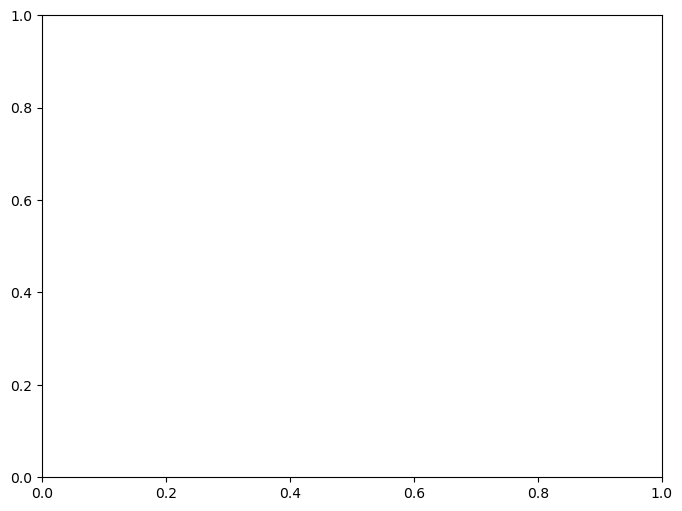

In [30]:
pltNspOneCol(path, 2)

In [198]:
    # Processing dumps


ValueError: Wrong number of files

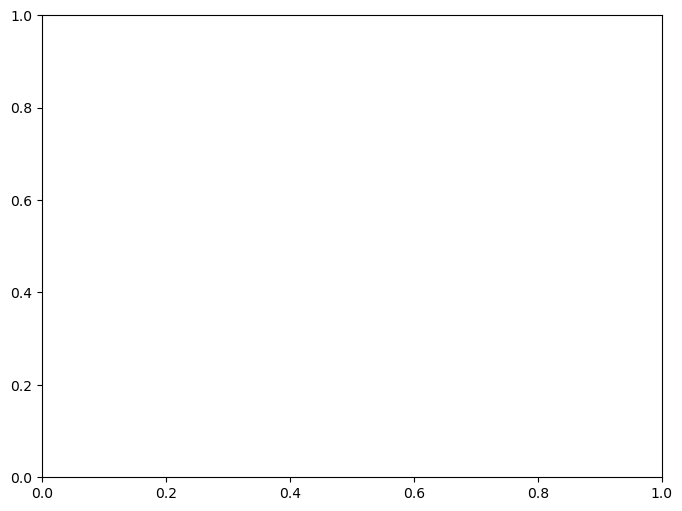

In [31]:
path = '/Users/laurent/data/TestPlan21-perfo/20241031_150830_errorBandShape-col2/dmx_data/'
colId=2
pltNspOneCol(path, colId, True, True, False)
